In [2]:
import os

print(os.listdir("/content"))


['.config', 'PhiUSIIL_Phishing_URL_Dataset.csv', 'sample_data']


In [3]:

import pandas as pd

df = pd.read_csv("/content/PhiUSIIL_Phishing_URL_Dataset.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (235795, 56)


,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


In [4]:

print("Missing values in each column:")
print(df.isnull().sum())

print("\nTotal missing values:")
print(df.isnull().sum().sum())

Missing values in each column:
FILENAME                      0
URL                           0
URLLength                     0
Domain                        0
DomainLength                  0
IsDomainIP                    0
TLD                           0
URLSimilarityIndex            0
CharContinuationRate          0
TLDLegitimateProb             0
URLCharProb                   0
TLDLength                     0
NoOfSubDomain                 0
HasObfuscation                0
NoOfObfuscatedChar            0
ObfuscationRatio              0
NoOfLettersInURL              0
LetterRatioInURL              0
NoOfDegitsInURL               0
DegitRatioInURL               0
NoOfEqualsInURL               0
NoOfQMarkInURL                0
NoOfAmpersandInURL            0
NoOfOtherSpecialCharsInURL    0
SpacialCharRatioInURL         0
IsHTTPS                       0
LineOfCode                    0
LargestLineLength             0
HasTitle                      0
Title                         0
DomainTit

In [5]:

print("Total duplicate rows:", df.duplicated().sum())


Total duplicate rows: 0


In [6]:

print("Column data types:")
print(df.dtypes)

print("\nLabel counts:")
print(df["label"].value_counts())

Column data types:
FILENAME                       object
URL                            object
URLLength                       int64
Domain                         object
DomainLength                    int64
IsDomainIP                      int64
TLD                            object
URLSimilarityIndex            float64
CharContinuationRate          float64
TLDLegitimateProb             float64
URLCharProb                   float64
TLDLength                       int64
NoOfSubDomain                   int64
HasObfuscation                  int64
NoOfObfuscatedChar              int64
ObfuscationRatio              float64
NoOfLettersInURL                int64
LetterRatioInURL              float64
NoOfDegitsInURL                 int64
DegitRatioInURL               float64
NoOfEqualsInURL                 int64
NoOfQMarkInURL                  int64
NoOfAmpersandInURL              int64
NoOfOtherSpecialCharsInURL      int64
SpacialCharRatioInURL         float64
IsHTTPS                        

In [7]:

print("First 10 column names:")
print(df.columns[:10].tolist())

print("\nLast 10 column names:")
print(df.columns[-10:].tolist())

First 10 column names:
['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb']

Last 10 column names:
['Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'label']


In [8]:

# Separate numeric and text columns
numeric_columns = df.select_dtypes(include="number").columns.tolist()
text_columns = df.select_dtypes(exclude="number").columns.tolist()

print("Number of numeric columns:", len(numeric_columns))
print("\nText columns:")
print(text_columns)

print("\nNumeric columns:")
print(numeric_columns)

Number of numeric columns: 51

Text columns:
['FILENAME', 'URL', 'Domain', 'TLD', 'Title']

Numeric columns:
['URLLength', 'DomainLength', 'IsDomainIP', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'label']


In [9]:

# PhishGuard — Day 3 data quality summary

print("DAY 3: DATA CLEANING SUMMARY")
print("-" * 35)
print("Dataset shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Numeric columns:", len(numeric_columns))
print("Text columns:", len(text_columns))
print("Label counts:")
print(df["label"].value_counts().sort_index())

DAY 3: DATA CLEANING SUMMARY
-----------------------------------
Dataset shape: (235795, 56)
Missing values: 0
Duplicate rows: 0
Numeric columns: 51
Text columns: 5
Label counts:
label
0    100945
1    134850
Name: count, dtype: int64


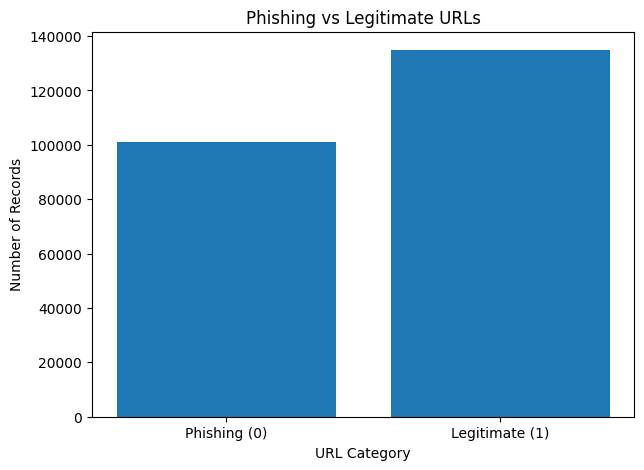

In [10]:

import matplotlib.pyplot as plt

label_counts = df["label"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(
    ["Phishing (0)", "Legitimate (1)"],
    [label_counts[0], label_counts[1]]
)

plt.title("Phishing vs Legitimate URLs")
plt.xlabel("URL Category")
plt.ylabel("Number of Records")
plt.show()

Average phishing URL length: 45.72029322898608
Average legitimate URL length: 26.228609566184648


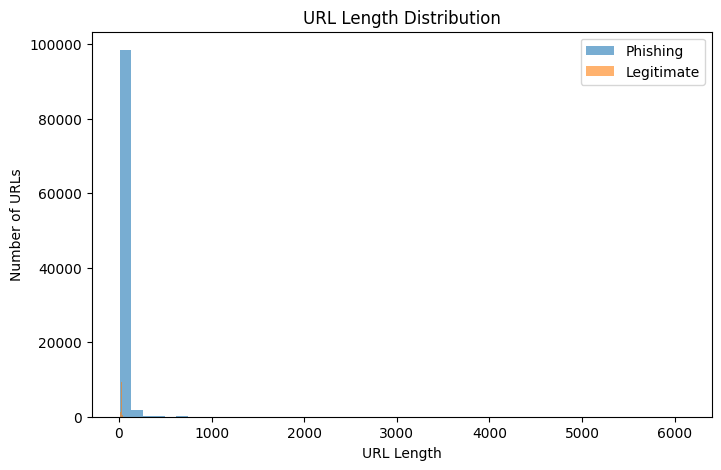

In [11]:

# Compare URL lengths for phishing and legitimate URLs

phishing_urls = df[df["label"] == 0]
legitimate_urls = df[df["label"] == 1]

print("Average phishing URL length:",
      phishing_urls["URLLength"].mean())

print("Average legitimate URL length:",
      legitimate_urls["URLLength"].mean())

plt.figure(figsize=(8, 5))

plt.hist(
    phishing_urls["URLLength"],
    bins=50,
    alpha=0.6,
    label="Phishing"
)

plt.hist(
    legitimate_urls["URLLength"],
    bins=50,
    alpha=0.6,
    label="Legitimate"
)

plt.title("URL Length Distribution")
plt.xlabel("URL Length")
plt.ylabel("Number of URLs")
plt.legend()
plt.show()

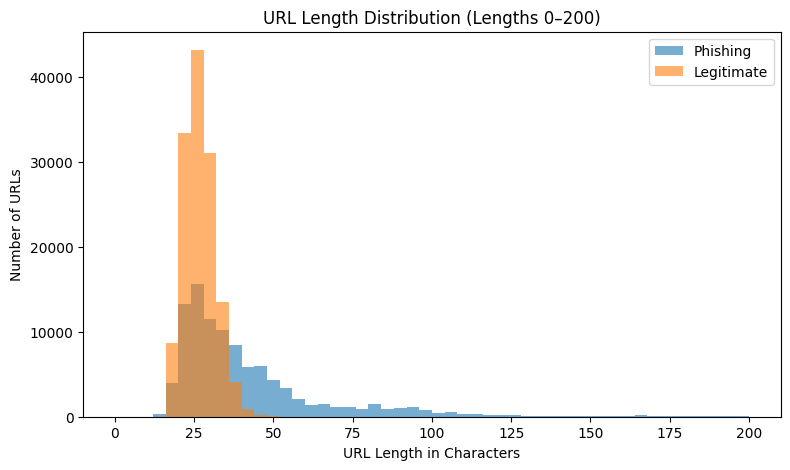

In [12]:

plt.figure(figsize=(9, 5))

plt.hist(
    phishing_urls["URLLength"],
    bins=50,
    range=(0, 200),
    alpha=0.6,
    label="Phishing"
)

plt.hist(
    legitimate_urls["URLLength"],
    bins=50,
    range=(0, 200),
    alpha=0.6,
    label="Legitimate"
)

plt.title("URL Length Distribution (Lengths 0–200)")
plt.xlabel("URL Length in Characters")
plt.ylabel("Number of URLs")
plt.legend()
plt.show()

Average IsHTTPS value by class:
label
0    0.492238
1    1.000000
Name: IsHTTPS, dtype: float64


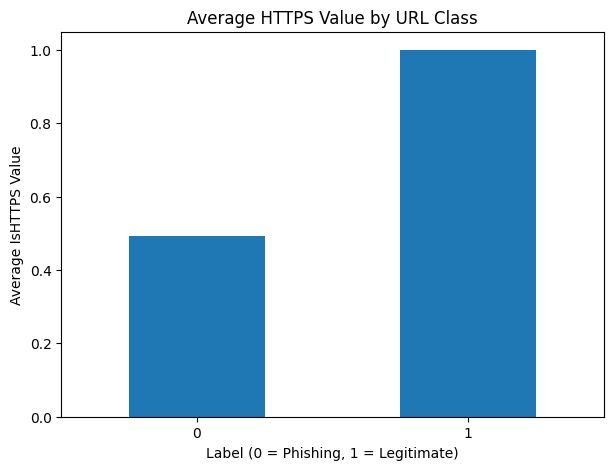

In [13]:

https_table = df.groupby("label")["IsHTTPS"].mean()

print("Average IsHTTPS value by class:")
print(https_table)

https_table.plot(
    kind="bar",
    figsize=(7, 5),
    title="Average HTTPS Value by URL Class",
    xlabel="Label (0 = Phishing, 1 = Legitimate)",
    ylabel="Average IsHTTPS Value"
)

plt.xticks(rotation=0)
plt.show()

In [14]:

# Display some features and the target label

print("Example input features:")
print(df[["URLLength", "IsHTTPS", "NoOfSubDomain"]].head())

print("\nTarget labels:")
print(df["label"].head())

Example input features:
   URLLength  IsHTTPS  NoOfSubDomain
0         31        1              1
1         23        1              1
2         29        1              2
3         26        1              1
4         33        1              1

Target labels:
0    1
1    1
2    1
3    1
4    1
Name: label, dtype: int64


In [15]:

# Compare feature values for phishing and legitimate URLs

print("Average feature values by label:")

print(
    df.groupby("label")[
        ["URLLength", "IsHTTPS", "NoOfSubDomain"]
    ].mean().round(3)
)

Average feature values by label:
       URLLength  IsHTTPS  NoOfSubDomain
label                                   
0         45.720    0.492          1.169
1         26.229    1.000          1.162


In [16]:
# Day 5: Check feature ranges

print("Minimum and maximum values:")

print(
    df[["URLLength", "IsHTTPS", "NoOfSubDomain"]]
    .agg(["min", "max"])
)

print("\nUnique values in IsHTTPS:")
print(sorted(df["IsHTTPS"].unique()))

print("\nUnique values in NoOfSubDomain:")
print(sorted(df["NoOfSubDomain"].unique()))

Minimum and maximum values:
     URLLength  IsHTTPS  NoOfSubDomain
min         13        0              0
max       6097        1             10

Unique values in IsHTTPS:
[np.int64(0), np.int64(1)]

Unique values in NoOfSubDomain:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10)]


In [17]:
# Find the 5 longest URLs

longest_urls = df.nlargest(5, "URLLength")[
    ["URL", "URLLength", "label"]
]

print(longest_urls.to_string(index=False))

In [18]:
# Day 5: Create a new feature

df["LongURL"] = (df["URLLength"] > 100).astype(int)

print("LongURL feature created successfully!")

print("\nLongURL counts:")
print(df["LongURL"].value_counts())

print("\nLongURL counts by label:")
print(pd.crosstab(df["label"], df["LongURL"]))

LongURL feature created successfully!

LongURL counts:
LongURL
0    230932
1      4863
Name: count, dtype: int64

LongURL counts by label:
LongURL       0     1
label                
0         96082  4863
1        134850     0


In [19]:
print("LongURL data type:", df["LongURL"].dtype)

print("\nMissing values in LongURL:")
print(df["LongURL"].isnull().sum())

print("\nUnique values in LongURL:")
print(sorted(df["LongURL"].unique()))

LongURL data type: int64

Missing values in LongURL:
0

Unique values in LongURL:
[np.int64(0), np.int64(1)]
